# VOCSegmentation (torchvision) + mały trening na GPU

Toy notebook do segmentacji: używa `torchvision.datasets.VOCSegmentation` (multi-class semantic segmentation) i trenuje mały U-Net na GPU (jeśli dostępny).

Maski VOC są per-piksel w zakresie klas `0..20` oraz mogą zawierać `255` jako `ignore_index`.

## 📝 Wielkie Zadanie: Budowa i Uruchomienie Sieci U-Net

**Zasoby i Dokumentacja:**
* Architektura referencyjna: [Pytorch-UNet na GitHub](https://github.com/milesial/pytorch-unet)
* Dokumentacja PyTorch: [Warstwy Konwolucyjne](https://pytorch.org/docs/stable/nn.html#convolution-layers)

### 🎯 Cel Edukacyjny
Celem nie jest uzyskanie idealnego modelu (segmentacja VOC jest trudna!), ale **zrozumienie przepływu danych w architekturze typu Encoder-Decoder** oraz poprawne połączenie warstw tak, aby proces uczenia w ogóle wystartował i zaczął generować sensowne maski.

### 🛠️ Twoje Zadania (Krok po Kroku):
1.  **Zdefiniowanie Bloku Konwolucyjnego (`ConvBlock`):** Uzupełnij warstwy tak, aby każdy blok składał się z dwóch operacji splotu (3x3), normalizacji batcha i aktywacji ReLU. Pamiętaj o zachowaniu wymiarów przestrzennych (padding!).
2.  **Konstrukcja Sieci (`SmallUNet`):** Dobierz liczby kanałów wejściowych i wyjściowych w konstruktorze `__init__`. Pamiętaj, że w dekoderze (po operacji `up`) łączysz cechy z enkodera, więc liczba kanałów wejściowych do `dec2` i `dec1` musi być sumą kanałów z 'dołu' i 'z boku' (skip-connection).
3.  **Dobór Hiperparametrów (`CONFIG`):**
    *   Zwiększ `epochs` (np. 10-20), aby model miał czas na naukę.
    *   Ustaw `max_steps_per_epoch` na `None`, by przejść przez cały zbiór.
    *   Eksperymentuj z parametrem `base` (np. 16, 32, 64) – im większy, tym model potężniejszy, ale wolniejszy.
4.  **Uruchomienie Treningu:** Sprawdź, czy `pixel_accuracy` rośnie, a funkcja kosztu maleje.

### ✅ Kryterium Sukcesu
Zadanie uznaje się za zaliczone, jeśli:
*   Kod modelu kompiluje się i wykonuje bez błędów wymiarów (*shape mismatch*).
*   Model zostanie wytrenowany przez co najmniej kilka epok.
*   Wizualizacja na końcu notebooka pokazuje, że model **próbuje** segmentować obiekty (nawet jeśli kontury są jeszcze nieprecyzyjne).

In [50]:
import random

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device: cuda


## CONFIG

In [51]:
# ZADANIE: Dobierz parametry tak, aby uzyskać satysfakcjonujące wyniki segmentacji.
CONFIG = {
    "data_root": "./data_voc",
    "image_size": 128,
    "batch_size": 8,
    "num_workers": 2,

    "num_classes": 21,
    "ignore_index": 255,

    "lr": 1e-3,
    "epochs": 30,           # Zwiększ liczbę epok
    "max_steps_per_epoch": None, # Ustaw None, aby trenować na pełnym zbiorze
}

print(CONFIG)

{'data_root': './data_voc', 'image_size': 128, 'batch_size': 8, 'num_workers': 2, 'num_classes': 21, 'ignore_index': 255, 'lr': 0.001, 'epochs': 30, 'max_steps_per_epoch': None}


In [52]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class VOCResizeWrapper(Dataset):
    def __init__(self, voc_dataset, image_size):
        self.voc = voc_dataset
        self.image_size = image_size

    def __len__(self):
        return len(self.voc)

    def __getitem__(self, idx):
        img, mask = self.voc[idx]  # PIL image + PIL mask

        img = img.resize((self.image_size, self.image_size), resample=Image.BILINEAR)
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)

        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)

        mask_np = np.array(mask, dtype=np.uint8)
        mask_t = torch.from_numpy(mask_np).long()  # [H, W]
        return img_t, mask_t


train_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="train",
    download=True,
)

val_base = datasets.VOCSegmentation(
    root=CONFIG["data_root"],
    year="2012",
    image_set="val",
    download=True,
)

train_ds = VOCResizeWrapper(train_base, CONFIG["image_size"])
val_ds = VOCResizeWrapper(val_base, CONFIG["image_size"])

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
)

img_t, mask_t = train_ds[0]
print("img_t:", img_t.shape, "mask_t:", mask_t.shape)
print("mask unique sample:", torch.unique(mask_t)[:10])


img_t: torch.Size([3, 128, 128]) mask_t: torch.Size([128, 128])
mask unique sample: tensor([  0,   1,  15, 255])


### Podgląd danych wejściowych (VOC)
Wyświetlamy kilka przykładowych obrazów ze zbioru treningowego wraz z ich maskami segmentacji.

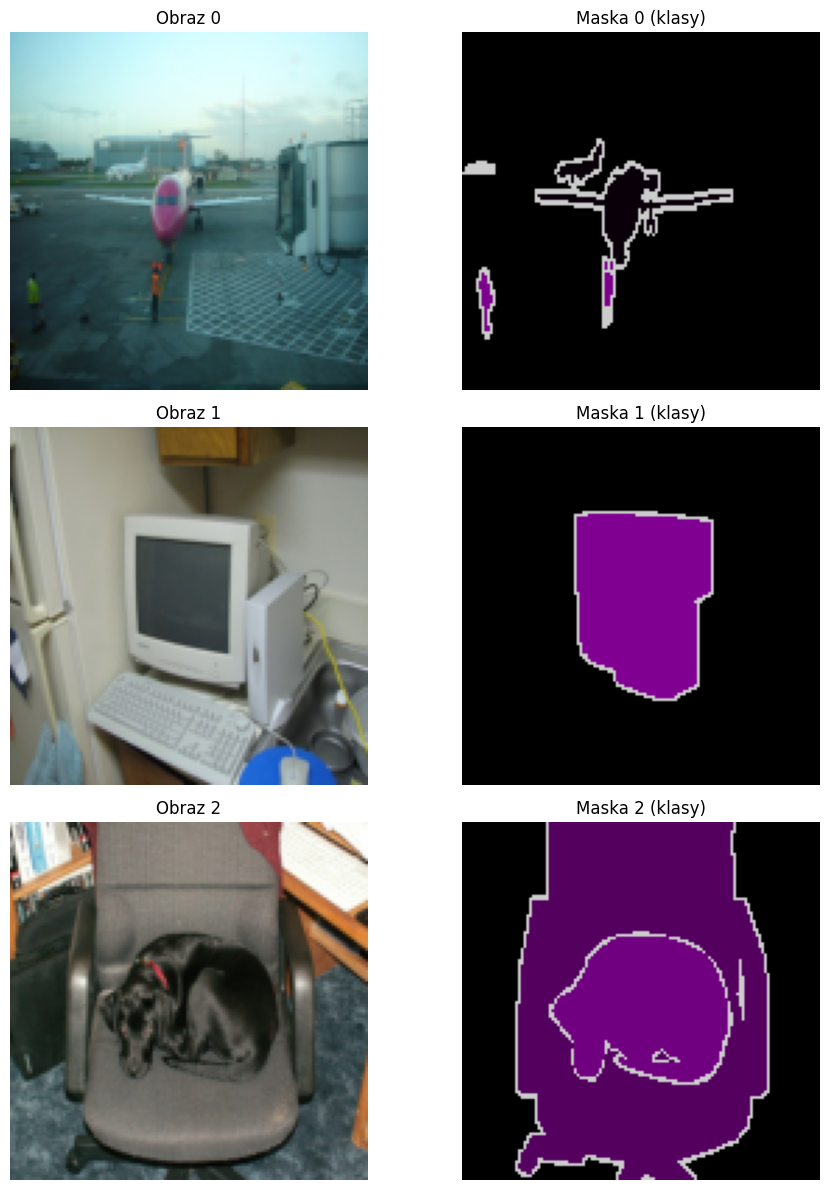

In [53]:
import matplotlib.pyplot as plt

def visualize_input_samples(dataset, num_samples=3):
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))
    for i in range(num_samples):
        img, mask = dataset[i]
        # Denormalizacja obrazu do wyświetlenia
        img_display = img.permute(1, 2, 0).numpy()
        img_display = img_display * IMAGENET_STD + IMAGENET_MEAN
        img_display = np.clip(img_display, 0, 1)

        axes[i, 0].imshow(img_display)
        axes[i, 0].set_title(f"Obraz {i}")
        axes[i, 0].axis('off')

        # Maska (mapujemy 255 na 0 dla lepszej widoczności lub zostawiamy jako raw)
        axes[i, 1].imshow(mask.numpy(), cmap='nipy_spectral')
        axes[i, 1].set_title(f"Maska {i} (klasy)")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

visualize_input_samples(train_ds)

In [54]:
import torch.nn as nn
import torch

class ConvBlock(nn.Module):
    """
    ZADANIE: Zaimplementuj blok: [Conv 3x3, BN, ReLU] x 2.
    Pamiętaj o padding=1, aby nie zmniejszać wymiarów obrazu.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # TODO: Zdefiniuj self.net jako nn.Sequential z odpowiednimi warstwami
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),

            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

class SmallUNet(nn.Module):
    """
    ZADANIE: Zdefiniuj warstwy encodera, bottlenecku i decodera w __init__.
    Dobierz kanały tak, aby pasowały do logiki konkatenacji w forward.
    """
    def __init__(self, in_channels=3, base=16, num_classes=21):
        super().__init__()
        # --- Encoder ---
        # TODO: zdefiniuj self.enc1, self.pool1, self.enc2, self.pool2
        self.enc1 = ConvBlock(in_ch=in_channels, out_ch=base)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc2 = ConvBlock(in_ch=base, out_ch=base*2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- Bottleneck ---
        # TODO: zdefiniuj self.bottleneck
        self.bottleneck = ConvBlock(in_ch=base*2, out_ch=base*4)

        # --- Decoder ---
        # TODO: zdefiniuj self.up2, self.dec2, self.up1, self.dec1
        # Wskazówka: self.dec2 przyjmuje kanały z (up2 + enc2)
        self.up2 = nn.ConvTranspose2d(in_channels=base*4, out_channels=base*2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(in_ch=base*4, out_ch=base*2)

        self.up1 = nn.ConvTranspose2d(in_channels=base*2, out_channels=base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(in_ch=base*2, out_ch=base)

        # --- Output ---
        # TODO: zdefiniuj self.final (Conv 1x1)
        self.final = nn.Conv2d(in_channels=base, out_channels=num_classes, kernel_size=1)


    def forward(self, x):
        # --- Encoder ---
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)

        # --- Bottleneck ---
        b = self.bottleneck(p2)

        # --- Decoder ze Skip-Connections ---
        u2 = self.up2(b)
        d2 = self.dec2(torch.cat([u2, s2], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, s1], dim=1))

        return self.final(d1)

# Inicjalizacja modelu - studenci mogą tu zmieniać parametr 'base'
model = SmallUNet(base=32).to(device)

In [55]:
criterion = nn.CrossEntropyLoss(ignore_index=CONFIG["ignore_index"])
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["lr"])

def pixel_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    valid = targets != CONFIG["ignore_index"]
    if valid.sum() == 0:
        return 0.0
    return (preds[valid] == targets[valid]).float().mean().item()


best_val_acc = -1.0

for epoch in range(CONFIG["epochs"]):
    model.train()
    running = 0.0
    steps = 0

    for step, (imgs, masks) in enumerate(train_loader):
        if CONFIG["max_steps_per_epoch"] is not None and step >= CONFIG["max_steps_per_epoch"]:
            break
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()
        steps += 1

    model.eval()
    accs = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(imgs)
            accs.append(pixel_accuracy(logits, masks))

    val_acc = float(np.mean(accs))
    train_loss = running / max(1, steps)
    best_val_acc = max(best_val_acc, val_acc)

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | train_loss={train_loss:.4f} | val_pixel_acc={val_acc:.4f}")

print("best_val_acc:", best_val_acc)


Epoch 1/30 | train_loss=1.6612 | val_pixel_acc=0.7245
Epoch 2/30 | train_loss=1.2408 | val_pixel_acc=0.7300
Epoch 3/30 | train_loss=1.2142 | val_pixel_acc=0.7301
Epoch 4/30 | train_loss=1.2058 | val_pixel_acc=0.7307
Epoch 5/30 | train_loss=1.1771 | val_pixel_acc=0.7321
Epoch 6/30 | train_loss=1.1587 | val_pixel_acc=0.7321
Epoch 7/30 | train_loss=1.1463 | val_pixel_acc=0.7319
Epoch 8/30 | train_loss=1.1284 | val_pixel_acc=0.7343
Epoch 9/30 | train_loss=1.1124 | val_pixel_acc=0.7329
Epoch 10/30 | train_loss=1.1037 | val_pixel_acc=0.7335
Epoch 11/30 | train_loss=1.0933 | val_pixel_acc=0.7333
Epoch 12/30 | train_loss=1.0838 | val_pixel_acc=0.7344
Epoch 13/30 | train_loss=1.0776 | val_pixel_acc=0.7352
Epoch 14/30 | train_loss=1.0662 | val_pixel_acc=0.7362
Epoch 15/30 | train_loss=1.0577 | val_pixel_acc=0.7352
Epoch 16/30 | train_loss=1.0511 | val_pixel_acc=0.7312
Epoch 17/30 | train_loss=1.0439 | val_pixel_acc=0.7342
Epoch 18/30 | train_loss=1.0287 | val_pixel_acc=0.7394
Epoch 19/30 | train

### Wizualizacja wyników treningu
Nakładamy przewidziane maski na obrazy walidacyjne oraz wyświetlamy legendę klas VOC.

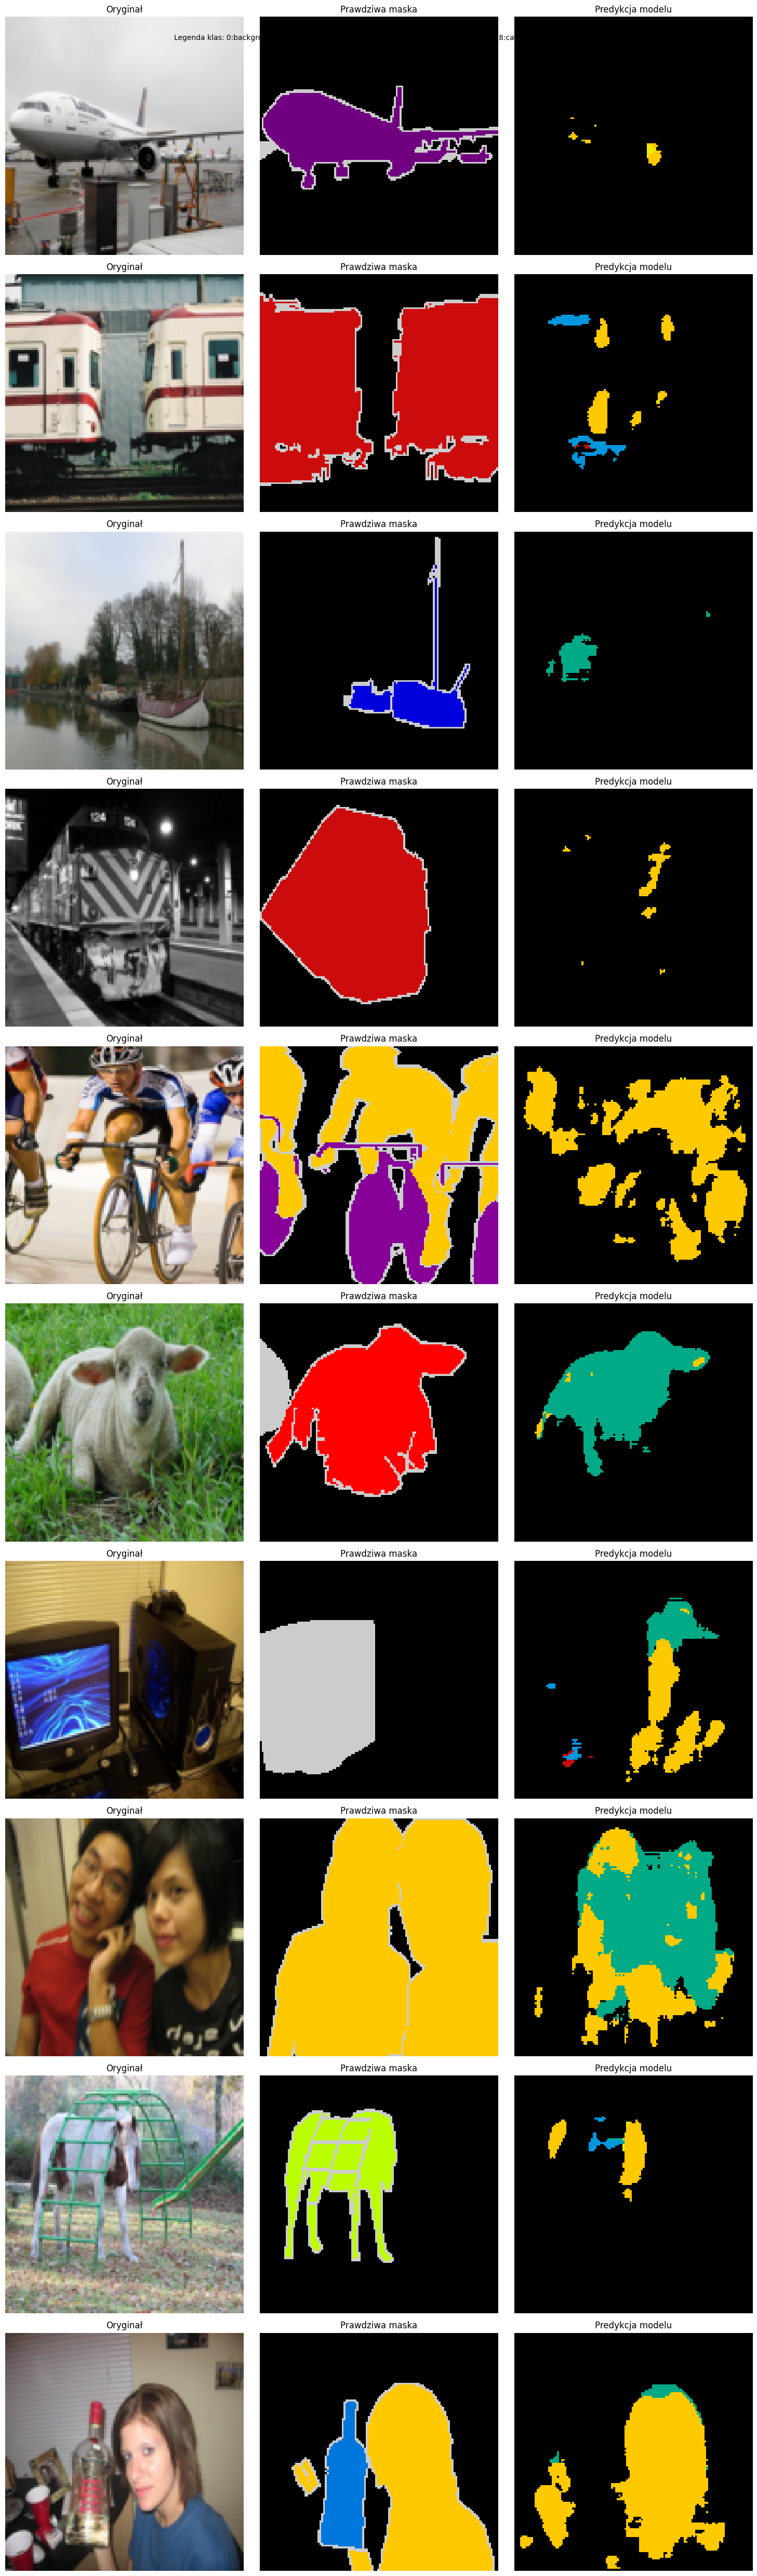

In [56]:
VOC_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow',
    'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

def visualize_predictions(model, dataset, device, num_samples=10):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))

    with torch.no_grad():
        for i in range(num_samples):
            img, mask = dataset[i]
            input_batch = img.unsqueeze(0).to(device)
            logits = model(input_batch)
            preds = logits.argmax(dim=1).cpu().squeeze(0)

            # Obraz oryginalny
            img_display = img.permute(1, 2, 0).numpy() * IMAGENET_STD + IMAGENET_MEAN
            img_display = np.clip(img_display, 0, 1)

            axes[i, 0].imshow(img_display)
            axes[i, 0].set_title("Oryginał")

            # Prawdziwa maska
            axes[i, 1].imshow(mask, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 1].set_title("Prawdziwa maska")

            # Predykcja
            axes[i, 2].imshow(preds, cmap='nipy_spectral', vmin=0, vmax=20)
            axes[i, 2].set_title("Predykcja modelu")

            for ax in axes[i]: ax.axis('off')

    plt.suptitle("Legenda klas: " + ", ".join([f"{i}:{c}" for i, c in enumerate(VOC_CLASSES[:11])]) + "...", fontsize=10)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_ds, device)

Przy `base` = 32, `epochs` = 15 loss spadał drastycznie po pierwszej epoce, a później się stabilizował, celność wynosiła około 73%. Działo się tak dlatego, że model nauczył się oznaczać wszystko jako tło, bo stanowi ono więszkość obrazka (na wizualizacji widać było czarną plamę).

Aby spełnić warunki zadania zmieniłem nieco hiperparametry, by zmusić model, by chociaż spróbował coś zakolorować.

Samo zwiększenie `epochs` do 20 już nieco poprawiło sytuację, ale nadal model był dość zachowawczy.
`base` = na 64 przy `epochs` pozostawionym na 15 i dało to słabe rezulataty, więszkość nadal była czarna.

Zatem zostałem przy `baze` = 32 i zwięszkałem ilość epok. `epoch` = 30 wydaje się miejscem przy którym model faktycznie zaczyna prawie zawsze coś rysować.

Przy tych hiperparametrach loss spada cały czas, a accuracy lawiruje w okolicach 74%, co nie daje rezultatu znacznie lepszego niż wynik przy 15 epokach, ale przynajmniej model osiąga to próbując coś narysować.